<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml09_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# 2진 분류(Binary Classifictaion) 문제

*   scikiet-learn에서 제공하는 breast cancer 데이터 셋 사용
*   Malignant(악성 종양) / Benign(음성) 분류
*   KNN
*   LogisticRegression
*   SGDClassifier

## Breast Cancer 데이터 셋 준비

In [2]:
bc = datasets.load_breast_cancer()

In [3]:
bc.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
x = bc.data  # features
y = bc.target  # target

In [5]:
x.shape

(569, 30)

In [6]:
y.shape

(569,)

## 데이터 탐색

In [7]:
# Breast Cancer 데이터 셋의 타겟 이름들
bc_target_names = bc.target_names
print(bc_target_names)  #> 0 - malignant, 1 - benign

['malignant' 'benign']


In [8]:
# 특성 배열을 데이터프레임으로 변환
bc_df = pd.DataFrame(data=x, columns=bc.feature_names)

In [9]:
bc_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
bc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [11]:
bc_df.describe()  # 기술 통계량

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


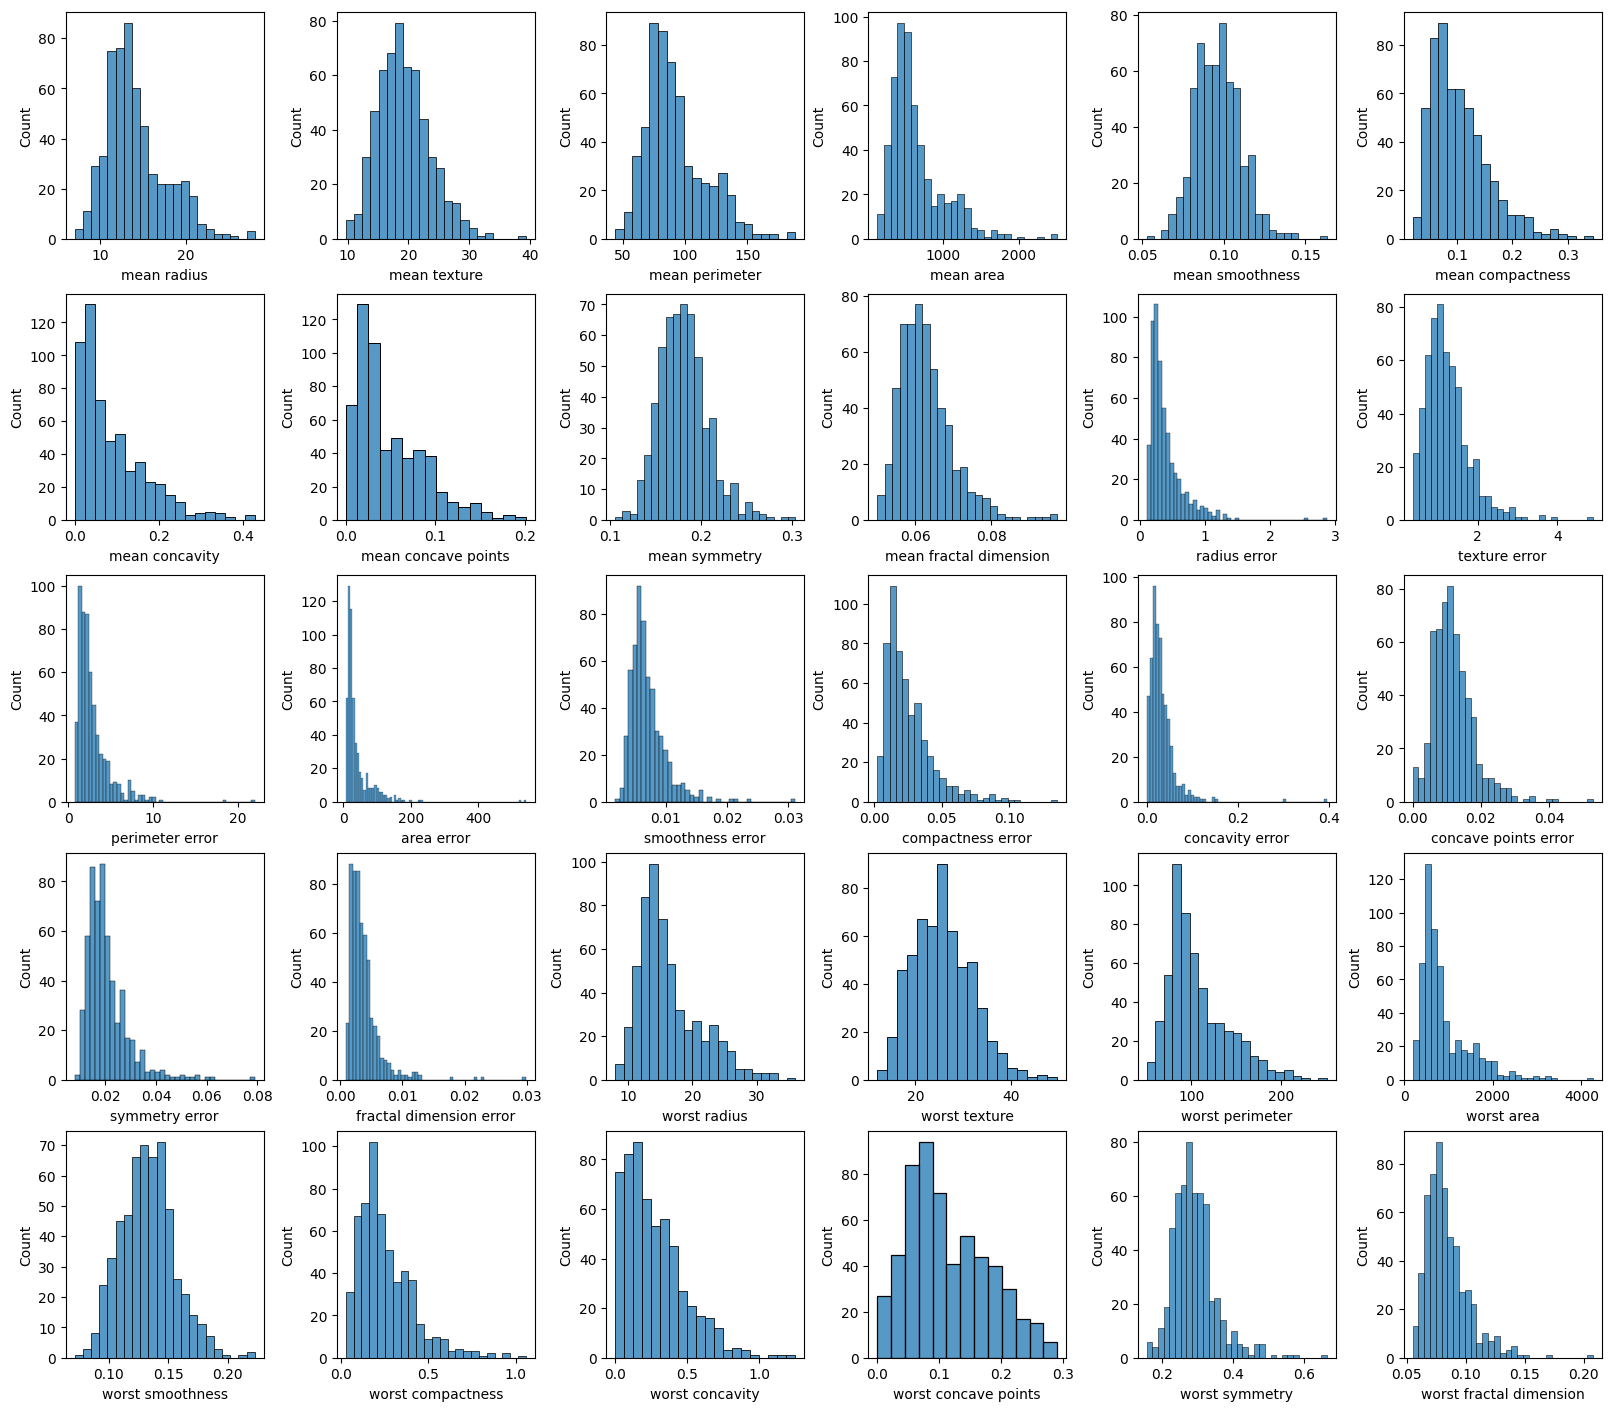

In [12]:
# 30개 특성들의 히스토그램을 시각화
fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(16,14), constrained_layout=True)

for i in range(5):
    for j in range(6):
        idx = i * 6 + j
        sns.histplot(data=bc_df, x=bc.feature_names[idx], ax=axes[i, j])

plt.show()

In [13]:
# 타겟(malignant/benign) 빈도수
bc_target_counts = pd.Series(y).value_counts()

In [14]:
bc_target_counts

,count
1,357
0,212


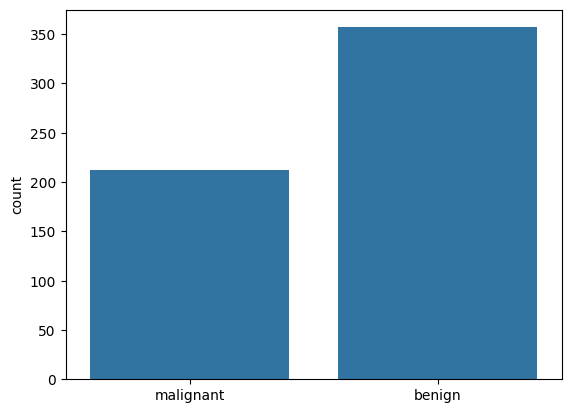

In [15]:
ax = sns.barplot(data=bc_target_counts)
ax.set_xticks(ticks=(0, 1), labels=bc_target_names)
plt.show()

## 훈련 셋 vs 테스트 셋 나누기

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [17]:
x_train.shape, x_test.shape

((455, 30), (114, 30))

In [18]:
y_train.shape, y_test.shape

((455,), (114,))

## KNN

In [19]:
# ML 모델 생성
pipe_knn = Pipeline(steps=[('scaler', StandardScaler()),
                           ('clf', KNeighborsClassifier())])

In [20]:
# ML 모델 훈련
pipe_knn.fit(X=x_train, y=y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])

In [21]:
# 훈련 셋 예측값
train_pred = pipe_knn.predict(X=x_train)

In [22]:
train_report = classification_report(y_true=y_train, y_pred=train_pred,
                                     target_names=bc_target_names)
print(train_report)

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96       170
      benign       0.97      0.99      0.98       285

    accuracy                           0.97       455
   macro avg       0.98      0.97      0.97       455
weighted avg       0.97      0.97      0.97       455



In [23]:
train_cm = confusion_matrix(y_true=y_train, y_pred=train_pred)
print(train_cm)

[[161   9]
 [  3 282]]


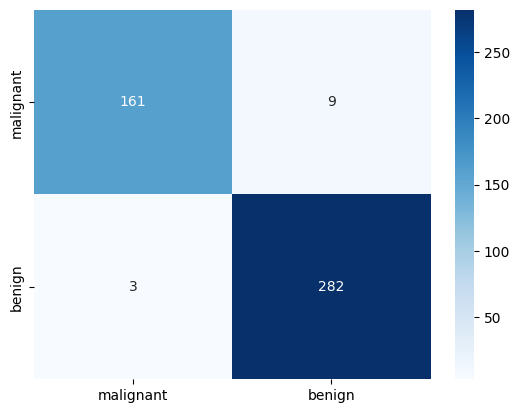

In [24]:
sns.heatmap(data=train_cm, cmap='Blues', annot=True, fmt='.0f',
            xticklabels=bc_target_names, yticklabels=bc_target_names)
plt.show()

## ROC Curve vs PR Curve

### ROC(Receiver Operating Characteristic) Curve

*   FPR을 x축으로 하고, TPR을 y축으로 설정해서 FPR과 TPR 사이의 관계를 나타낸 곡선.
*   FPR(False Positive Rate, 가짜 양성 비율): 실제 음성 샘플들 중에서 오답(가짜 양성)의 비율.
    *   FPR = FP / (FP + TN)
*   TPR(True Positive Rate, 진짜 양성 비율): 실제 양성 샘플들 중에서 정답(진짜 양성)의 비율. 재현율(recall).
    *   TPR = TP / (TP + FN)
*   TNR(True Negative Rate, 진짜 음성 비율): 실제 음성 샘플들 중에서 정답(진짜 음성)의 비율. 특이도(specificity).
    *   TNR = TN / (FP + TN)
    *   TNR + FPR = 1
    *   TNR = 1 - FPR
    *   FPR = 1 - TNR(specificity)
*   AUC(Area under curve): ROC 곡선 아래쪽의 넓이.
    *   이진 분류 성능 평가 - AUC가 1에 가까울 수록 좋은 모델.

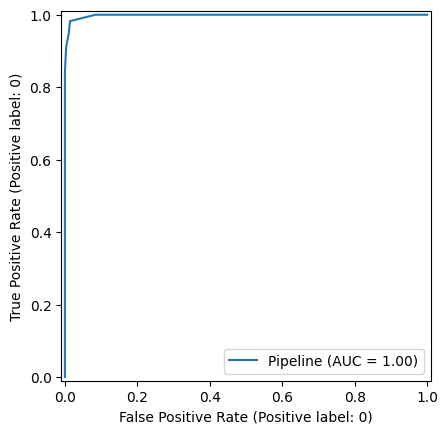

In [25]:
RocCurveDisplay.from_estimator(estimator=pipe_knn, X=x_train, y=y_train,
                               pos_label=0)
plt.show()

### PR(Precision-Recall) Curve

*   정밀도(precision)와 재현율(recall)은 trade-off 관계가 있음.
*   같은 정확도(accuracy)에서 정밀도가 좋아지면 재현율이 나빠지고, 재현율이 좋아지면 정밀도가 나빠짐.
    *   재현율을 x축으로, 정밀도를 y축으로 설정해서 trade-off 관계를 나타낸 그래프.
    *   AP(Average Precision): PR Curve 아래의 면적
    *   AP가 1에 가까울 수록 좋은 모델.

| 구분 | ROC Curve | PR Curve |
| :--- | :---| :--- |
| X축 / Y축 | FPR / TPR(Recall) | Recall(재현율) / Precision(정밀도) |
| 주요 관심사 | 모델이 양성과 음성을 얼마나 잘 분류하는가? | 모델이 양수(Positive) 클래스를 얼마나 정확히 잡아내는가? |
| 추천 데이터 | 균형 데이터셋 (양성과 음성의 비율이 비슷할 때) | 불균형 데이터셋 (찾고자 하는 양성 데이터가 매우 적을 때) |
| 음성(Negative) 반영 | 진짜 음성(TN)의 양이 계산에 큰 영향을 줌 | 진짜 음성(TN)의 양을 완전히 무시함 |

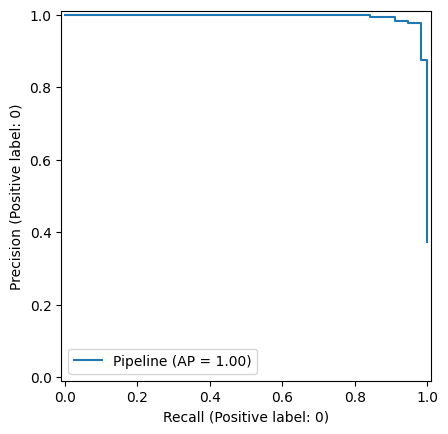

In [26]:
PrecisionRecallDisplay.from_estimator(estimator=pipe_knn, X=x_train, y=y_train,
                                      pos_label=0)
plt.show()